In [33]:
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np

# CamemBERT = BERT entraîné sur du français
MODEL_NAME = "camembert-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)
model.eval()  # mode inférence(pas d'entraînement)

device = torch.device("cpu") 
model = model.to(device)

print(f"Modèle chargé sur : {device}")

Loading weights: 100%|█████████████████████████████████████████████| 199/199 [00:00<00:00, 4170.08it/s]
[transformers] CamembertModel LOAD REPORT from: camembert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modèle chargé sur : cpu


In [34]:
#extraction embedding 
def get_word_embedding(phrase, mot, tokenizer, model):

    # Étape 1 : transformer la phrase en tenseurs pour BERT
    inputs = tokenizer(phrase, return_tensors="pt",
                       truncation=True, max_length=512).to(device)

    # Étape 2 : récupérer la liste des tokens
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    # ex: ['<s>', '▁La', '▁fra', 'ise', '▁est', '▁rouge', '</s>']

    # Étape 3 : reconstruire les mots en collant les sous-tokens
    # CamemBERT découpe parfois "fraise" en "▁fra" + "ise"
    # On recolle les morceaux pour retrouver le mot entier
    mot_lower = mot.lower()
    indices = []

    i = 0
    while i < len(tokens):

        # Nettoyer le token : enlever ▁ et mettre en minuscules
        token_propre = tokens[i].replace("▁", "").lower()

        # Construire le mot en collant les sous-tokens suivants
        mot_reconstruit = token_propre
        j = i + 1
        while j < len(tokens):
            suite = tokens[j].replace("▁", "").lower()
            # Si le token suivant commence par ▁ c'est un nouveau mot : stop
            if tokens[j].startswith("▁"):
                break
            mot_reconstruit += suite
            j += 1

        # Est-ce que le mot reconstruit correspond au mot cherché ?
        if mot_reconstruit == mot_lower:
            indices = list(range(i, j))
            break

        i += 1

    # Si le mot n'a pas été trouvé dans les tokens : ignorer cette phrase
    if not indices:
        return None

    # Étape 4 : faire tourner BERT pour obtenir les vecteurs
    with torch.no_grad():
        outputs = model(**inputs)

    # Étape 5 : extraire le vecteur du mot cible
    # last_hidden_state contient un vecteur de 768 dimensions par token
    tous_les_vecteurs = outputs.last_hidden_state[0]

    # Prendre la moyenne si le mot a été découpé en plusieurs sous-tokens
    vecteur_du_mot = tous_les_vecteurs[indices].mean(dim=0)

    # Convertir en tableau numpy et retourner
    return vecteur_du_mot.cpu().numpy()

In [35]:
embeddings = {}   # embeddings[mot] = liste de vecteurs numpy (768-dim)
phrases_retenues = {}  # pour garder une trace des phrases utilisées

for mot, phrases in corpus.items():
    
    vecteurs = []
    phrases_ok = []
    
    for phrase in phrases:
        vec = get_word_embedding(phrase, mot, tokenizer, model)
       
        if vec is not None:
            vecteurs.append(vec)
            phrases_ok.append(phrase)
  
    embeddings[mot] = vecteurs #tableau numpy
    phrases_retenues[mot] = phrases_ok
    print(f" {mot:15s} : {len(vecteurs)} embeddings extraits (dim={vecteurs[0].shape})")

 café            : 54 embeddings extraits (dim=(768,))
 souris          : 56 embeddings extraits (dim=(768,))
 langue          : 76 embeddings extraits (dim=(768,))
 fraise          : 79 embeddings extraits (dim=(768,))
 avocat          : 47 embeddings extraits (dim=(768,))
 bois            : 26 embeddings extraits (dim=(768,))
 livre           : 83 embeddings extraits (dim=(768,))
 vol             : 31 embeddings extraits (dim=(768,))
 action          : 28 embeddings extraits (dim=(768,))
 tour            : 76 embeddings extraits (dim=(768,))
 médecin         : 14 embeddings extraits (dim=(768,))
 volcan          : 35 embeddings extraits (dim=(768,))
 pentathlon      : 29 embeddings extraits (dim=(768,))
 atome           : 24 embeddings extraits (dim=(768,))
 photosynthèse   : 24 embeddings extraits (dim=(768,))
 chrysanthème    : 12 embeddings extraits (dim=(768,))
 hydrogène       : 28 embeddings extraits (dim=(768,))
 électron        : 23 embeddings extraits (dim=(768,))
 antibioti

In [36]:
#score polysémie 
from scipy.spatial.distance import cosine
from itertools import combinations
import numpy as np

def score_polysemie(vecteurs, n_max=50):
    """
    Score = écart-type des similarités cosinus 2-à-2.
    Plus le score est élevé, plus les vecteurs sont dispersés → mot polysémique.
    """
    # Limiter le nombre de paires pour éviter une explosion combinatoire
    vecs = vecteurs[:n_max]
    
    similarites = []
    for v1, v2 in combinations(vecs, 2):
        sim = 1 - cosine(v1, v2)  # similarité cosinus ∈ [-1, 1]
        similarites.append(sim)
    
    similarites = np.array(similarites)
    return {
        "score":   np.std(similarites),   # écart-type = score de polysémie
        "sim_moy": np.mean(similarites),  # similarité moyenne
        "n_paires": len(similarites)
    }

# Calcul pour tous les mots
resultats = {}
for mot, vecs in embeddings.items():
    resultats[mot] = score_polysemie(vecs)
    print(f"{mot:15s}  score={resultats[mot]['score']:.4f}  "
          f"sim_moy={resultats[mot]['sim_moy']:.4f}  "
          f"n_paires={resultats[mot]['n_paires']}")

café             score=0.1016  sim_moy=0.8021  n_paires=1225
souris           score=0.1403  sim_moy=0.7197  n_paires=1225
langue           score=0.1211  sim_moy=0.7517  n_paires=1225
fraise           score=0.0773  sim_moy=0.8397  n_paires=1225
avocat           score=0.1506  sim_moy=0.7176  n_paires=1081
bois             score=0.1526  sim_moy=0.7832  n_paires=325
livre            score=0.1594  sim_moy=0.7031  n_paires=1225
vol              score=0.1073  sim_moy=0.7658  n_paires=465
action           score=0.1350  sim_moy=0.7351  n_paires=378
tour             score=0.1481  sim_moy=0.6833  n_paires=1225
médecin          score=0.1141  sim_moy=0.7700  n_paires=91
volcan           score=0.1413  sim_moy=0.8398  n_paires=595
pentathlon       score=0.0915  sim_moy=0.8765  n_paires=406
atome            score=0.1077  sim_moy=0.7808  n_paires=276
photosynthèse    score=0.0430  sim_moy=0.8961  n_paires=276
chrysanthème     score=0.0615  sim_moy=0.8820  n_paires=66
hydrogène        score=0.1505  sim_

In [37]:
#recap des resultats
import pandas as pd

df = pd.DataFrame([
    {
        "mot": mot,
        "score_polysemie": resultats[mot]["score"],
        "sim_moyenne": resultats[mot]["sim_moy"],
        "type": "polysémique" if mot in mots_polysemique else "monosémique"
    }
    for mot in resultats
]).sort_values("score_polysemie", ascending=False)

print(df.to_string(index=False))

          mot  score_polysemie  sim_moyenne        type
        livre         0.159374     0.703063 polysémique
         bois         0.152607     0.783230 polysémique
       avocat         0.150639     0.717648 polysémique
    hydrogène         0.150541     0.790951 monosémique
         tour         0.148089     0.683295 polysémique
       volcan         0.141316     0.839767 monosémique
       souris         0.140290     0.719677 polysémique
       action         0.134978     0.735117 polysémique
       langue         0.121074     0.751688 polysémique
      médecin         0.114098     0.770012 monosémique
        atome         0.107675     0.780794 monosémique
          vol         0.107268     0.765802 polysémique
         café         0.101553     0.802080 polysémique
   pentathlon         0.091545     0.876479 monosémique
       fraise         0.077317     0.839705 polysémique
 chrysanthème         0.061539     0.881965 monosémique
     électron         0.055990     0.896029 mono

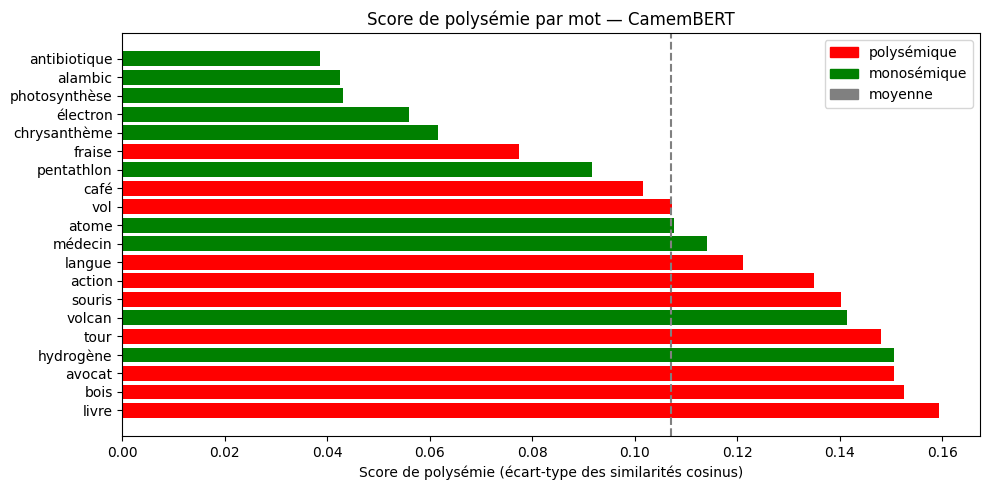

In [38]:
#vizualisation
import matplotlib.pyplot as plt

couleurs = df["type"].map({"polysémique": "red", "monosémique": "green"})

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(df["mot"], df["score_polysemie"], color=couleurs)
ax.set_xlabel("Score de polysémie (écart-type des similarités cosinus)")
ax.set_title("Score de polysémie par mot — CamemBERT")
ax.axvline(df["score_polysemie"].mean(), color="gray", linestyle="--", label="moyenne")

# Légende manuelle
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="red", label="polysémique"),
    Patch(color="green", label="monosémique"),
    Patch(color="gray",    label="moyenne")
])

plt.tight_layout()
plt.savefig("score_polysemie.png")
plt.show()

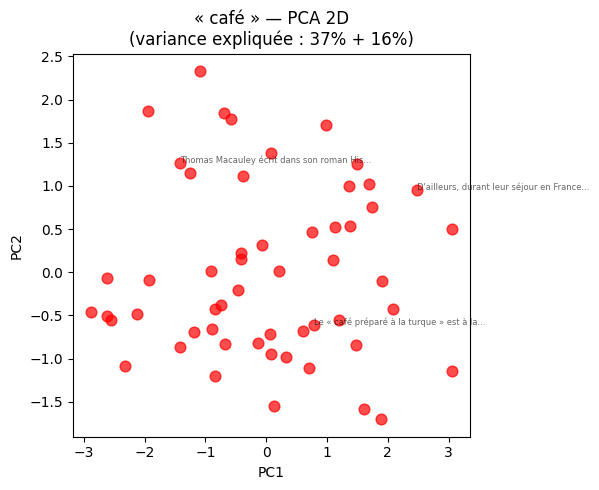

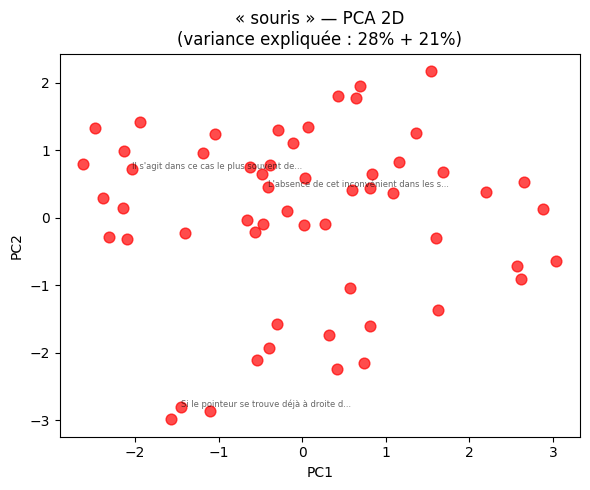

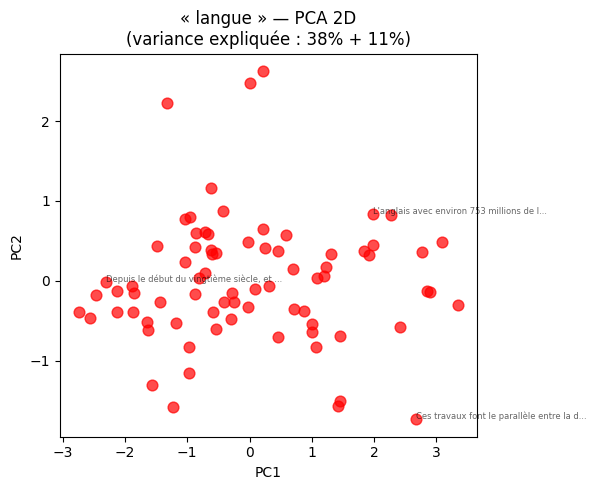

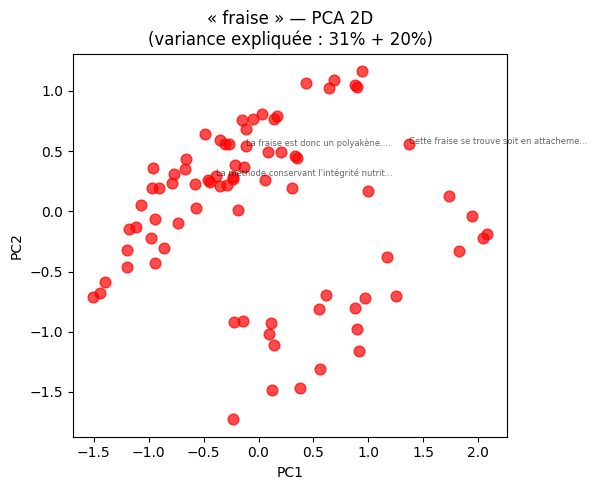

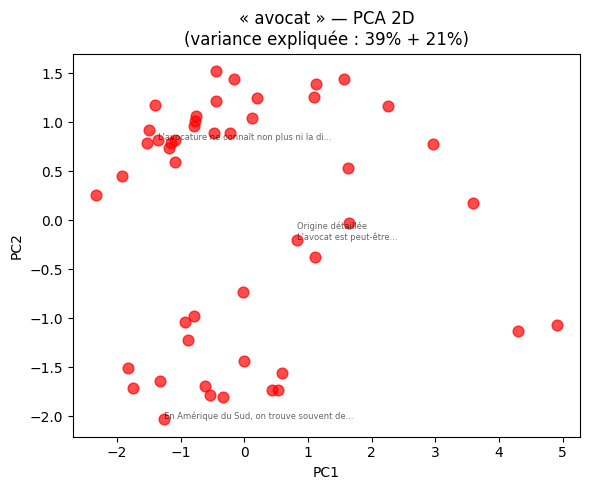

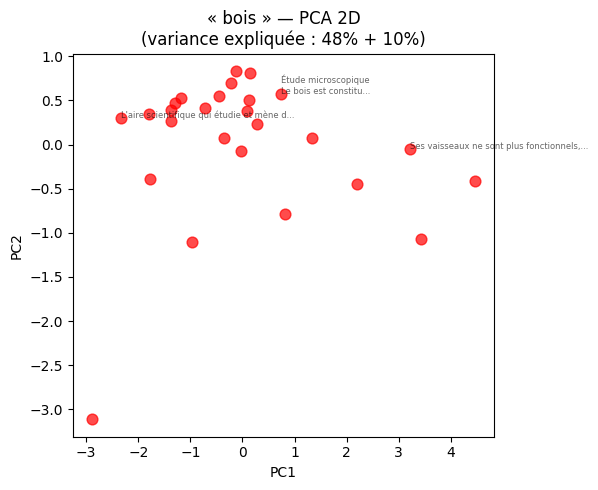

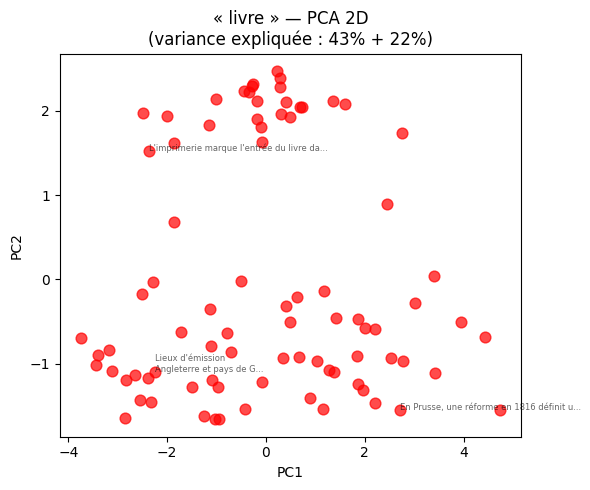

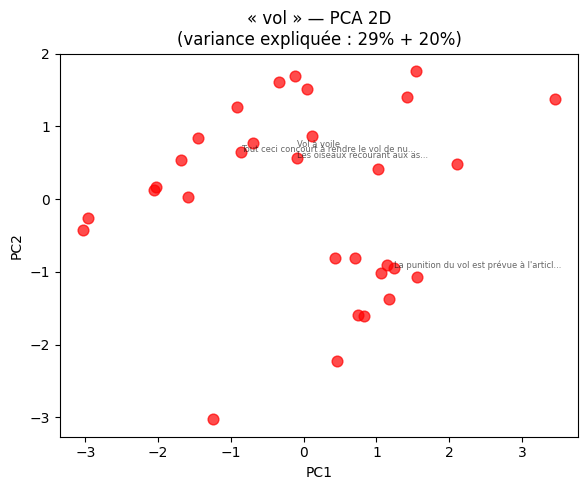

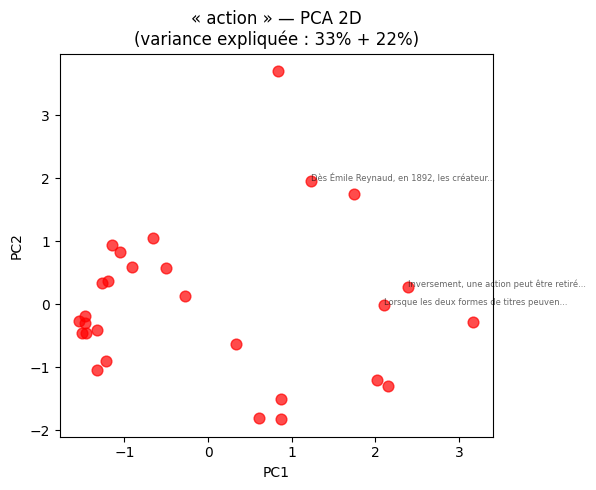

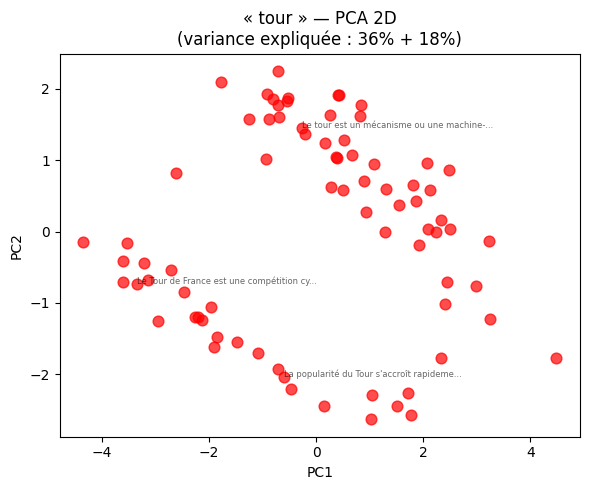

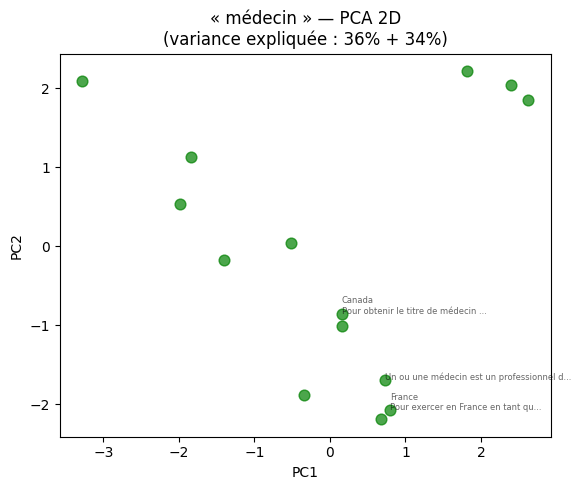

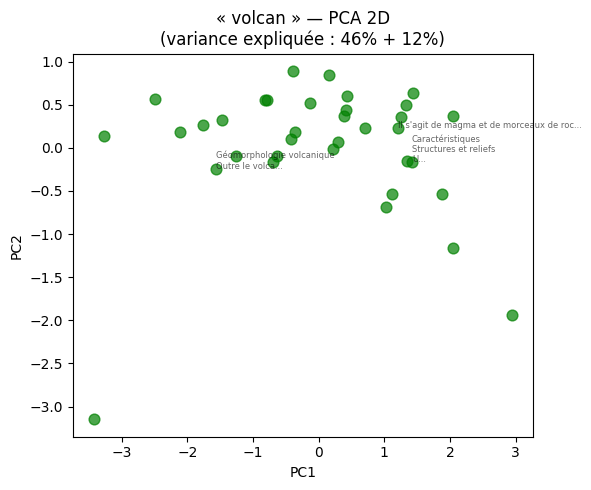

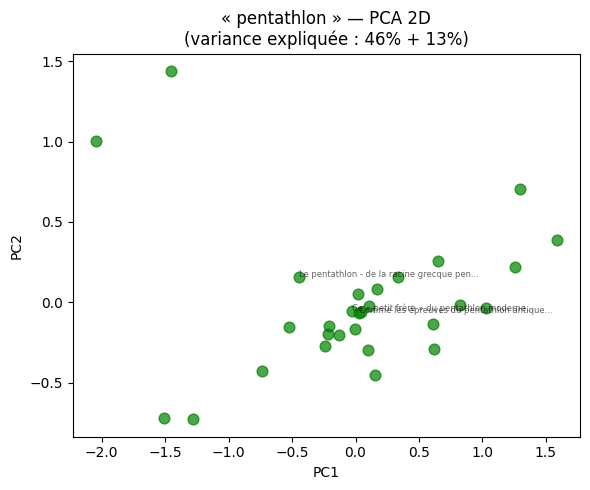

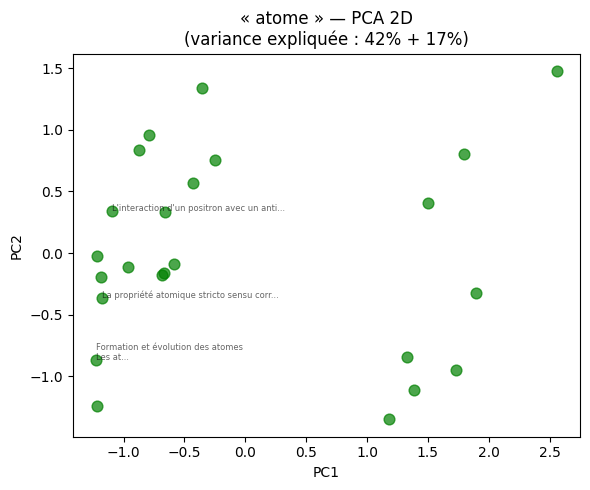

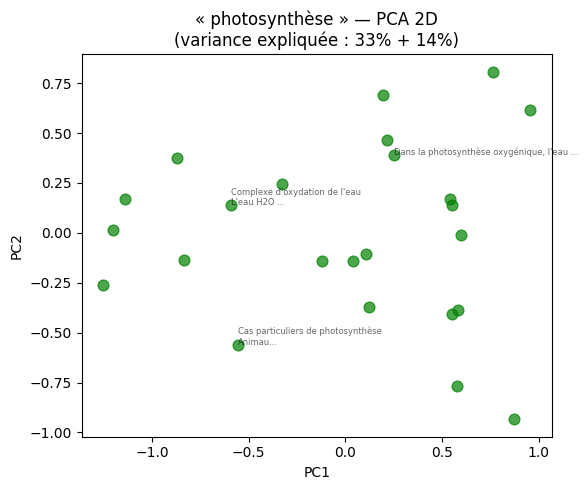

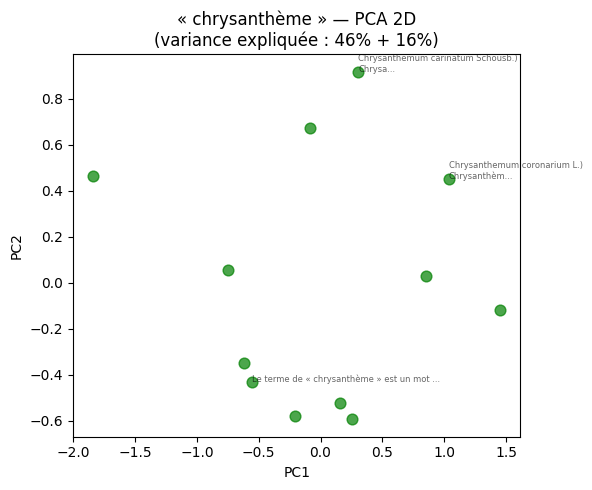

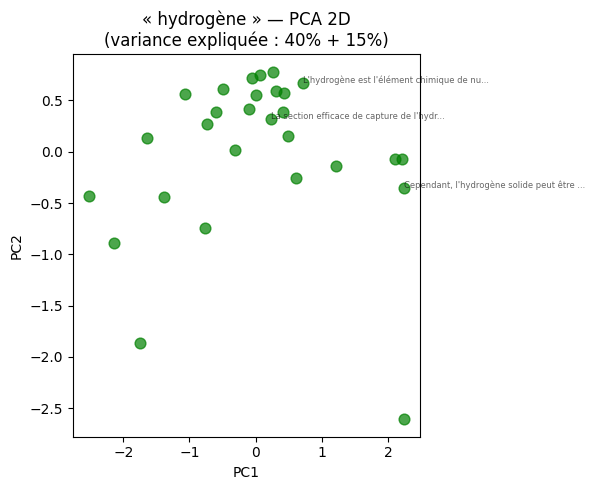

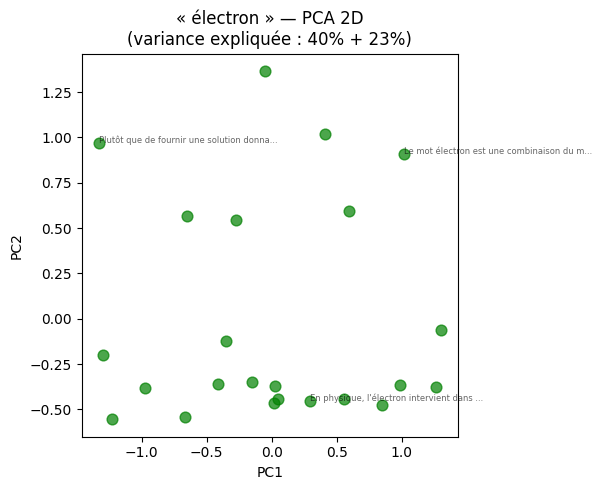

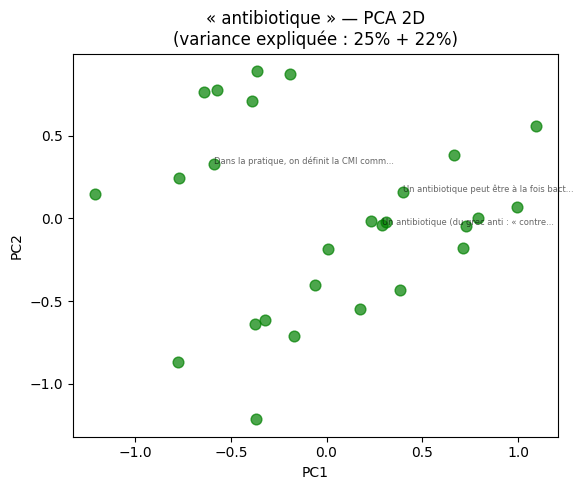

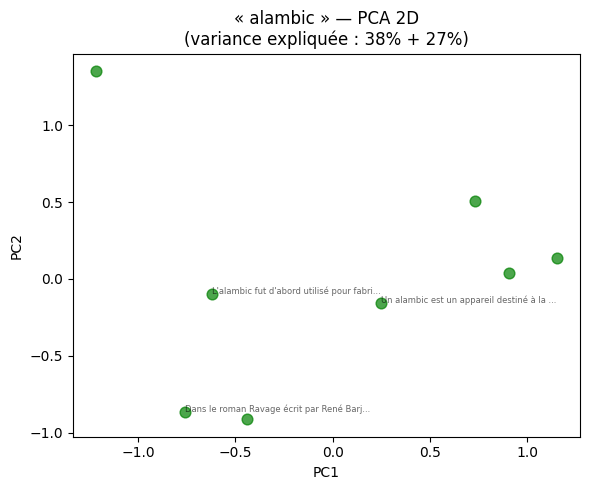

In [40]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def viz_mot_isole(mot, embeddings, n_exemples=3):
    vecs = np.array(embeddings[mot])
    
    # PCA 
    pca = PCA(n_components=2)
    coords = pca.fit_transform(vecs)
    
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(coords[:, 0], coords[:, 1], alpha=0.7, s=60,
               color="red" if mot in mots_polysemique else "green")
    
    # Annoter quelques phrases pour interpréter les clusters
    for i in range(min(n_exemples, len(coords))):
        phrase_courte = phrases_retenues[mot][i][:40] + "..."
        ax.annotate(phrase_courte, (coords[i, 0], coords[i, 1]),
                    fontsize=6, alpha=0.6)
    
    variance = pca.explained_variance_ratio_
    ax.set_title(f"« {mot} » — PCA 2D\n"
                 f"(variance expliquée : {variance[0]:.0%} + {variance[1]:.0%})")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    plt.tight_layout()
    plt.savefig(f"viz_{mot}.png", dpi=150)
    plt.show()

# Ne faire que les mots les plus pertinent 
for mot in mots_cible:
    viz_mot_isole(mot, embeddings)

In [22]:
from sklearn.manifold import TSNE
# Construire les listes globales
all_vecs  = []   # tous les vecteurs
all_mots  = []   # le mot correspondant à chaque vecteur
all_types = []   # "polysémique" ou "monosémique"

for mot in embeddings:
    for vec in embeddings[mot]:
        all_vecs.append(vec)
        all_mots.append(mot)
        all_types.append("polysémique" if mot in mots_polysemique else "monosémique")

X = np.array(all_vecs)
print(f"Matrice globale : {X.shape}")

Matrice globale : (754, 768)


In [41]:
# Une couleur par mot (pour distinguer les mots entre eux)
mots_uniques = list(embeddings.keys())
palette = plt.cm.tab20.colors  # 20 couleurs distinctes

couleur_par_mot  = {mot: palette[i % 20] for i, mot in enumerate(mots_uniques)}
couleurs_points  = [couleur_par_mot[m] for m in all_mots]

# Forme du marqueur selon le type
marqueur_par_type = {"polysémique": "o", "monosémique": "^"}
marqueurs = [marqueur_par_type[t] for t in all_types]

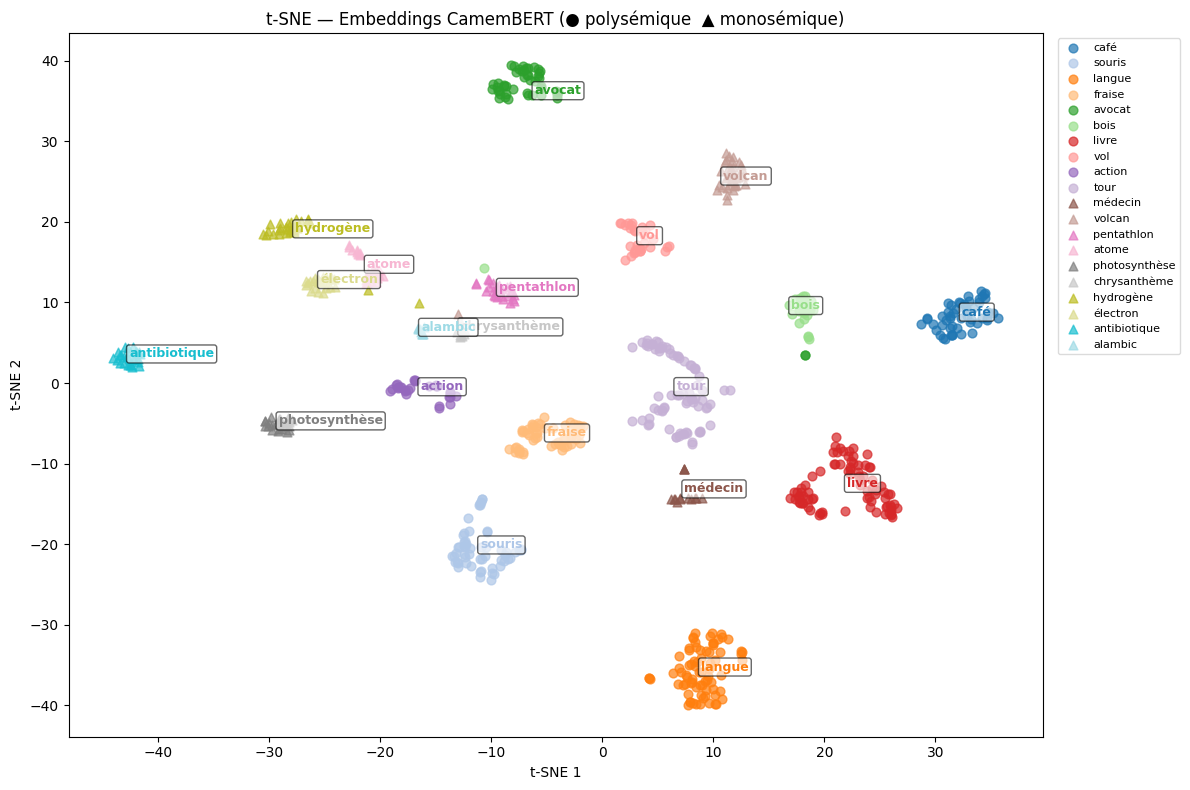

Sauvegardé : tsne_global.png


In [42]:
reducer_tsne = TSNE(n_components=2, perplexity=30,
                    random_state=42, max_iter=1000)
X_tsne = reducer_tsne.fit_transform(X)

fig, ax = plt.subplots(figsize=(12, 8))

for mot in mots_uniques:
    idx = [i for i, m in enumerate(all_mots) if m == mot]
    coords = X_tsne[idx]
    marker = "o" if mot in mots_polysemique else "^"
    ax.scatter(coords[:, 0], coords[:, 1],
               color=couleur_par_mot[mot],
               marker=marker, alpha=0.7, s=40, label=mot)
    ax.annotate(mot, xy=(coords[:, 0].mean(), coords[:, 1].mean()),
                fontsize=9, fontweight="bold",
                color=couleur_par_mot[mot],
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6))

ax.set_title("t-SNE — Embeddings CamemBERT (● polysémique  ▲ monosémique)")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8,
          ncol=1, framealpha=0.7)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
plt.tight_layout()
plt.savefig("tsne_global.png", dpi=150, bbox_inches="tight")
plt.show()
print("Sauvegardé : tsne_global.png")

In [43]:
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')  # Open Multilingual WordNet (inclut le français)

from nltk.corpus import wordnet as wn

# Test
print(wn.synsets('chat', lang='fra'))
print(wn.synsets('chaise', lang='fra'))

[nltk_data] Downloading package wordnet to /home/salmach/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/salmach/nltk_data...


[Synset('computerized_tomography.n.01'), Synset('cat.v.01'), Synset('felis.n.01'), Synset('cat.n.01'), Synset('tom.n.02'), Synset('big_cat.n.01'), Synset('caterpillar.n.02'), Synset('cat-o'-nine-tails.n.01'), Synset('kat.n.01'), Synset('spade.n.02'), Synset('tom.n.01'), Synset('cat.n.03'), Synset('guy.n.01')]
[Synset('professorship.n.01'), Synset('moderate.v.01'), Synset('chair.v.01'), Synset('chair.n.01'), Synset('electric_chair.n.01'), Synset('seat.n.03')]


[nltk_data]   Package omw-1.4 is already up-to-date!


In [44]:
def nb_sens_wordnet(mot, lang='fra'):
    """Nombre de synsets = proxy du nombre de sens linguistiques."""
    synsets = wn.synsets(mot, lang=lang)
    return len(synsets)

# Calculer pour tous les mots
nb_sens = {}
for mot in embeddings.keys():
    n = nb_sens_wordnet(mot)
    nb_sens[mot] = n
    print(f"{mot:15s} : {n} sens dans WordNet")

café            : 6 sens dans WordNet
souris          : 5 sens dans WordNet
langue          : 14 sens dans WordNet
fraise          : 6 sens dans WordNet
avocat          : 8 sens dans WordNet
bois            : 13 sens dans WordNet
livre           : 19 sens dans WordNet
vol             : 7 sens dans WordNet
action          : 17 sens dans WordNet
tour            : 18 sens dans WordNet
médecin         : 7 sens dans WordNet
volcan          : 2 sens dans WordNet
pentathlon      : 1 sens dans WordNet
atome           : 2 sens dans WordNet
photosynthèse   : 1 sens dans WordNet
chrysanthème    : 2 sens dans WordNet
hydrogène       : 1 sens dans WordNet
électron        : 1 sens dans WordNet
antibiotique    : 2 sens dans WordNet
alambic         : 1 sens dans WordNet


In [45]:
from scipy.stats import spearmanr, pearsonr

# Aligner les deux mesures
df_corr = pd.DataFrame({
    "mot":            list(resultats.keys()),
    "score_bert":     [resultats[m]["score"] for m in resultats],
    "nb_sens_wordnet":[nb_sens[m] for m in resultats],
    "type":           ["polysémique" if m in mots_polysemique 
                       else "monosémique" for m in resultats]
})

print(df_corr.sort_values("score_bert", ascending=False).to_string(index=False))

          mot  score_bert  nb_sens_wordnet        type
        livre    0.159374               19 polysémique
         bois    0.152607               13 polysémique
       avocat    0.150639                8 polysémique
    hydrogène    0.150541                1 monosémique
         tour    0.148089               18 polysémique
       volcan    0.141316                2 monosémique
       souris    0.140290                5 polysémique
       action    0.134978               17 polysémique
       langue    0.121074               14 polysémique
      médecin    0.114098                7 monosémique
        atome    0.107675                2 monosémique
          vol    0.107268                7 polysémique
         café    0.101553                6 polysémique
   pentathlon    0.091545                1 monosémique
       fraise    0.077317                6 polysémique
 chrysanthème    0.061539                2 monosémique
     électron    0.055990                1 monosémique
photosynth

In [49]:
x = df_corr["score_bert"].values
y = df_corr["nb_sens_wordnet"].values

rho, p_value = spearmanr(x, y)
r, p_pearson = pearsonr(x, y)

print(f"Corrélation de Spearman : ρ = {rho:.3f}  (p = {p_value:.4f})")
print(f"Corrélation de Pearson  : r = {r:.3f}  (p = {p_pearson:.4f})")

if p_value < 0.05:
    print(" Corrélation significative (p < 0.05)")
else:
    print("Corrélation non significative ")

Corrélation de Spearman : ρ = 0.629  (p = 0.0029)
Corrélation de Pearson  : r = 0.625  (p = 0.0032)
 Corrélation significative (p < 0.05)


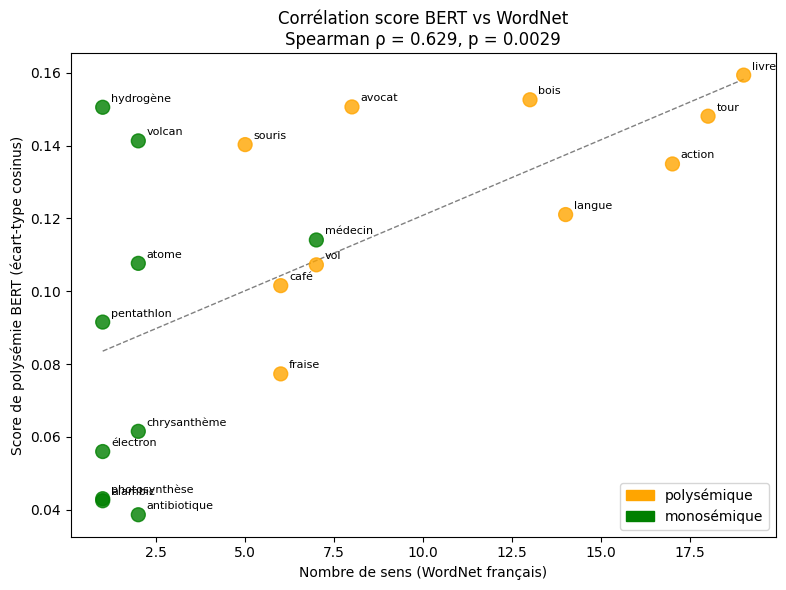

In [48]:
fig, ax = plt.subplots(figsize=(8, 6))

couleurs = df_corr["type"].map({"polysémique": "orange", "monosémique": "green"})
ax.scatter(df_corr["nb_sens_wordnet"], df_corr["score_bert"],
           c=couleurs, s=100, alpha=0.8, zorder=3)

# Annoter chaque point avec le nom du mot
for _, row in df_corr.iterrows():
    ax.annotate(row["mot"],
                (row["nb_sens_wordnet"], row["score_bert"]),
                textcoords="offset points", xytext=(6, 4), fontsize=8)

# Droite de régression
m, b = np.polyfit(df_corr["nb_sens_wordnet"], df_corr["score_bert"], 1)
x_line = np.linspace(df_corr["nb_sens_wordnet"].min(),
                     df_corr["nb_sens_wordnet"].max(), 100)
ax.plot(x_line, m * x_line + b, color="gray", linestyle="--", linewidth=1)

ax.set_xlabel("Nombre de sens (WordNet français)")
ax.set_ylabel("Score de polysémie BERT (écart-type cosinus)")
ax.set_title(f"Corrélation score BERT vs WordNet\n"
             f"Spearman ρ = {rho:.3f}, p = {p_value:.4f}")

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="orange", label="polysémique"),
    Patch(color="green", label="monosémique")
])

plt.tight_layout()
plt.savefig("correlation_wordnet.png", dpi=150)
plt.show()